# Imports

In [1]:
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from collections import deque

# Configuration

In [2]:
# Account
INITIAL_BALANCE = 10_000
RISK_PER_TRADE = 0.10
LEVERAGE = 1.0

# Costs/Fees
TAKER_FEE_RATE = 0.0010
SLIPPAGE_RATE = 0.0005
ONE_WAY_COST = TAKER_FEE_RATE + SLIPPAGE_RATE

# Data
BASE_URL = "https://data-api.binance.vision"
SYMBOL = "BTCUSDT"
BAR_SIZE = "1h"

# Data Window
START = "2015-07-01 00:00:00"
END   = "2026-08-01 00:00:00"

# Parameters
HORIZON = 37
THRESHOLD_MULTIPLIER = 1.0          # multiply round-trip cost
ALLOW_SHORTS = True

# Model Parameters
LR = 0.00325
MODEL_L2 = 0.425

# Parameters Study Grid
HORIZON_GRID = [36, 37, 38]
THRESHOLD_MULTIPLIER_GRID = [0.80, 1.0, 1.2]

# Hyperparameters Study Grid
LR_GRID = [0.00300, 0.00325, 0.00350]
MODEL_L2_GRID = [0.400, 0.425, 0.450]
#37	1.0	0.00325	0.425

# Data Loader

In [3]:
def load_data(symbol, start, end, interval, limit=1000):
    start_ms = int(pd.Timestamp(start, tz="UTC").timestamp() * 1000)
    end_ms = int(pd.Timestamp(end, tz="UTC").timestamp() * 1000)

    all_rows = []
    current_start = start_ms

    while current_start < end_ms:
        url = f"{BASE_URL}/api/v3/klines"
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": limit,
        }

        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        rows = r.json()

        if not rows:
            break

        all_rows.extend(rows)

        last_open_time = rows[-1][0]
        next_start = last_open_time + 1

        if next_start <= current_start:
            break

        current_start = next_start
        time.sleep(0.05)

    if not all_rows:
        raise ValueError("No data returned from Binance.")

    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
    ]

    df = pd.DataFrame(all_rows, columns=cols)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", utc=True)

    numeric_cols = [
        "open", "high", "low", "close", "volume",
        "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"
    ]

    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.sort_values("open_time").drop_duplicates("open_time").reset_index(drop=True)
    df = df.set_index("open_time")

    return df

# Load Raw Data

In [4]:
raw_df = load_data(SYMBOL, START, END, BAR_SIZE)
raw_df.head()

,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
open_time,,,,,,,,,,,
2017-08-17 04:00:00+00:00,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:59:59.999000+00:00,202366.138393,171,35.160503,150952.477943,0
2017-08-17 05:00:00+00:00,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:59:59.999000+00:00,100304.823567,102,21.448071,92608.279728,0
2017-08-17 06:00:00+00:00,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:59:59.999000+00:00,31282.312670,36,4.802861,20795.317224,0
2017-08-17 07:00:00+00:00,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:59:59.999000+00:00,19241.058300,25,2.602292,11291.347015,0
2017-08-17 08:00:00+00:00,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:59:59.999000+00:00,4239.503586,28,0.814655,3552.746817,0


# Data Checks

In [5]:
print(raw_df.shape)
print(raw_df.index.min(), "to", raw_df.index.max())
print(raw_df.isna().sum().sort_values(ascending=False))

(78373, 11)
2017-08-17 04:00:00+00:00 to 2026-08-01 00:00:00+00:00
open                            0
high                            0
low                             0
close                           0
volume                          0
close_time                      0
quote_asset_volume              0
number_of_trades                0
taker_buy_base_asset_volume     0
taker_buy_quote_asset_volume    0
ignore                          0
dtype: int64


# Feature Engineering

In [6]:
def build_features(raw_df, horizon=30):
    df = raw_df.copy()
    eps = 1e-12

    # Past multi-horizon log returns
    return_windows = [125, 150, 175, 200, 225, 250]
    for window in return_windows:
        df[f"ret_{window}"] = np.log(df["close"] / df["close"].shift(window))

    # Target
    df["future_log_return_h"] = np.log(
        df["close"].shift(-horizon) / df["close"]
    )

    # Log return bar over bar
    df["future_log_return_1"] = np.log(
        df["close"].shift(-1) / df["close"]
    )

    feature_cols = (
        [f"ret_{w}" for w in return_windows]
    )

    df = df.replace([np.inf, -np.inf], np.nan).dropna().copy()

    return df, feature_cols, "future_log_return_h", "future_log_return_1"

# Build Modeling Dataset

In [7]:
df, feature_cols, target_col, pnl_col = build_features(raw_df, HORIZON)

print("Rows:", len(df))
print("Features:", len(feature_cols))
print(feature_cols)
df[[target_col] + feature_cols].describe().T

Rows: 78086
Features: 6
['ret_125', 'ret_150', 'ret_175', 'ret_200', 'ret_225', 'ret_250']


,count,mean,std,min,25%,50%,75%,max
future_log_return_h,78086.0,0.001279,0.043481,-0.640916,-0.017453,0.001305,0.020744,0.304585
ret_125,78086.0,0.004365,0.080218,-0.765076,-0.033380,0.003543,0.044378,0.451863
ret_150,78086.0,0.005261,0.088439,-0.788206,-0.035935,0.003892,0.049073,0.489689
ret_175,78086.0,0.006146,0.096317,-0.791006,-0.039575,0.005043,0.052806,0.598987
ret_200,78086.0,0.007039,0.103324,-0.747531,-0.042381,0.005979,0.057795,0.570061
ret_225,78086.0,0.007922,0.109544,-0.750965,-0.045606,0.007099,0.062154,0.555237
ret_250,78086.0,0.008788,0.115663,-0.758010,-0.049390,0.007616,0.066680,0.604372


# Data Visualization

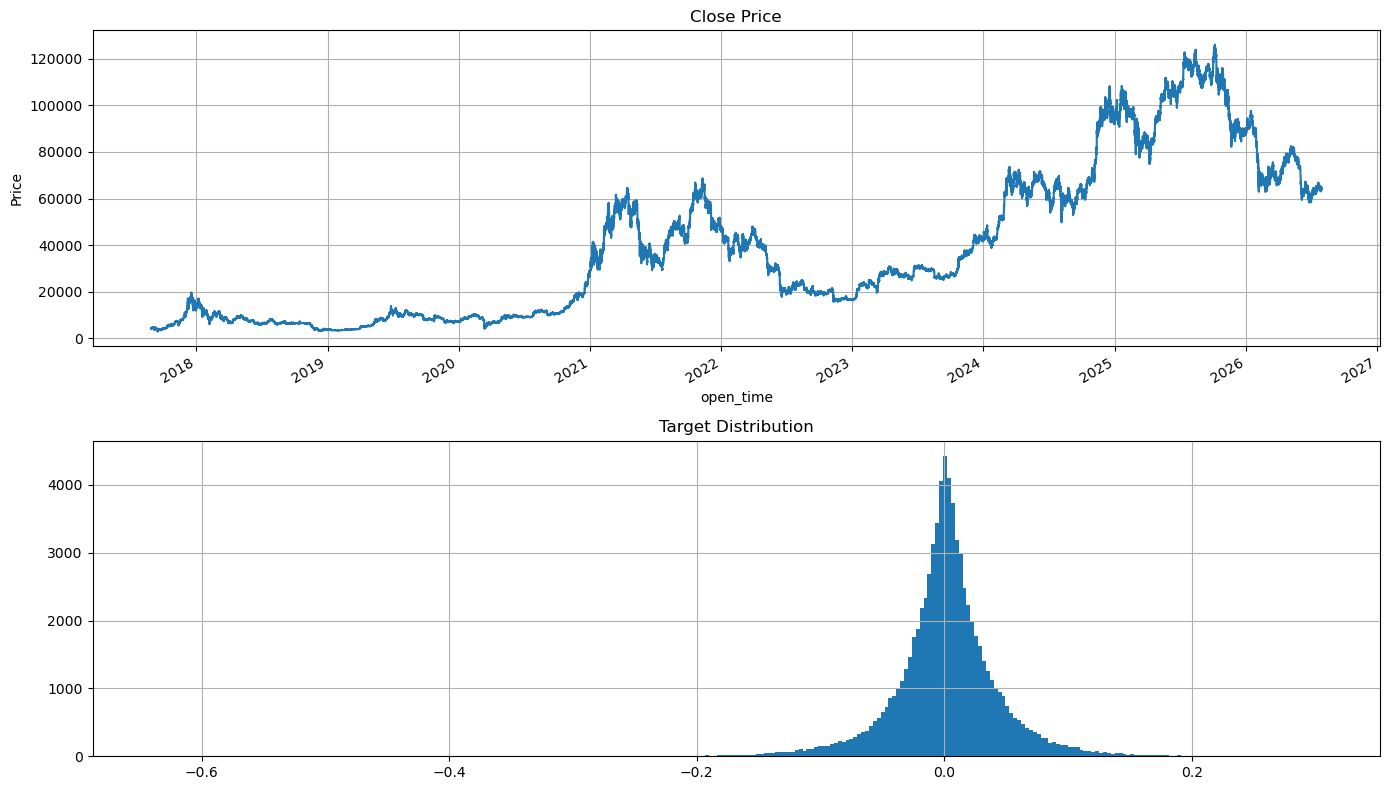

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

df["close"].plot(ax=ax[0], title="Close Price", grid=True)
df[target_col].hist(ax=ax[1], bins=300, grid=True)

ax[0].set_ylabel("Price")
ax[1].set_title("Target Distribution")
plt.tight_layout()
plt.show()

# Linear Regression Model

In [9]:
class LinearRegressionModel:
    def __init__(self, n_features, lr=0.001, model_l2=0.0):
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.lr = lr
        self.model_l2 = model_l2

    def predict(self, x):
        x = np.asarray(x, dtype=float).reshape(-1)
        return float(np.dot(self.w, x) + self.b)

    def update(self, x, y):
        x = np.asarray(x, dtype=float).reshape(-1)
        y = float(y)

        pred = self.predict(x)
        err = pred - y

        self.w -= self.lr * (err * x + self.model_l2 * self.w)
        self.b -= self.lr * err

        return err

# Regression Metrics

In [10]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(y_true, y_pred)[0, 1]

    direction_acc = np.mean(np.sign(y_true) == np.sign(y_pred))

    return {
        "mse": float(mse),
        "mae": float(mae),
        "corr": float(corr) if not np.isnan(corr) else np.nan,
        "direction_acc": float(direction_acc),
    }


def max_drawdown(equity_curve):
    eq = np.asarray(equity_curve, dtype=float)
    peaks = np.maximum.accumulate(eq)
    drawdowns = (eq - peaks) / peaks
    return float(drawdowns.min())


def sharpe_ratio(returns, bars_per_year=24*365):
    rets = np.asarray(returns, dtype=float)
    if len(rets) < 2 or np.std(rets) == 0:
        return np.nan
    return float(np.sqrt(bars_per_year) * rets.mean() / rets.std())

# Trading Rule

In [11]:
def prediction_to_position(pred, threshold, allow_shorts=True):
    threshold = abs(threshold)
    if pred > threshold:
        return 1
    elif allow_shorts and pred < -threshold:
        return -1
    else:
        return 0

# Walk-Forward Evaluation

In [12]:
def walk_forward_simulation(
    df,
    feature_cols,
    target_col,           # e.g. future_log_return_h
    pnl_return_col,       # e.g. future_log_return_1
    horizon=30,
    lr=0.01,
    model_l2=0.0001,
    threshold_multiplier=1.25,
    allow_shorts=True,
    initial_balance=10_000.0
):
    threshold = threshold_multiplier * ONE_WAY_COST

    X = df[feature_cols].to_numpy()
    y = df[target_col].to_numpy()
    y_pnl = df[pnl_return_col].to_numpy()

    model = LinearRegressionModel(
        n_features=len(feature_cols),
        lr=lr,
        model_l2=model_l2
    )

    preds = []
    positions = []
    pnl_dollars = []
    pnl_pct = []
    equity_curve = [initial_balance]

    prev_position = 0
    pending_updates = deque()
    seen_samples = 0

    for i in range(len(df)):
        # 1) update model only with samples whose horizon outcome is now known
        while pending_updates and pending_updates[0][0] <= i:
            _, x_ready, y_ready = pending_updates.popleft()
            model.update(x_ready, y_ready)
            seen_samples += 1

        x_i = X[i]
        y_i = y[i]
        pnl_logret_i = y_pnl[i]

        # 2) predict current horizon return
        pred = model.predict(x_i)
        pred = float(np.clip(pred, -0.2, 0.2))

        position = prediction_to_position(
            pred,
            threshold,
            allow_shorts=allow_shorts
        )

        # 3) mark-to-market using next-bar realized return
        simple_return_1 = np.exp(pnl_logret_i) - 1.0

        position_size = equity_curve[-1] * LEVERAGE * RISK_PER_TRADE
        turnover = abs(position - prev_position)

        costs = ONE_WAY_COST * turnover * position_size
        gross_pnl = position * simple_return_1 * position_size
        net_pnl = gross_pnl - costs

        new_equity = equity_curve[-1] + net_pnl

        preds.append(pred)
        positions.append(position)
        pnl_dollars.append(net_pnl)
        pnl_pct.append(net_pnl / equity_curve[-1] if equity_curve[-1] != 0 else 0.0)
        equity_curve.append(new_equity)

        # 4) schedule current sample for update when label becomes known
        pending_updates.append((i + horizon, x_i.copy(), y_i))

        prev_position = position

    result = df.copy()
    result["prediction"] = preds
    result["position"] = positions
    result["strategy_pnl"] = pnl_dollars
    result["strategy_return"] = pnl_pct
    result["equity"] = equity_curve[1:]

    pred_metrics = regression_metrics(result[target_col], result["prediction"])

    prev_pos = result["position"].shift(1).fillna(0)
    trade_count = int((result["position"] != prev_pos).sum())
    long_count = int(((result["position"] == 1) & (prev_pos != 1)).sum())
    short_count = int(((result["position"] == -1) & (prev_pos != -1)).sum())
    flat_count = int(((result["position"] == 0) & (prev_pos != 0)).sum())

    trading_metrics = {
        "final_equity": float(result["equity"].iloc[-1]),
        "total_return": float(result["equity"].iloc[-1] / initial_balance - 1.0),
        "sharpe": sharpe_ratio(result["strategy_return"]),
        "max_drawdown": max_drawdown(result["equity"]),
        "trade_count": trade_count,
        "long_count": long_count,
        "short_count": short_count,
        "flat_count": flat_count,
        "avg_bar_return": float(result["strategy_return"].mean()),
    }

    return result, pred_metrics, trading_metrics

# Baseline Run

In [13]:
baseline_result, baseline_pred_metrics, baseline_trading_metrics = walk_forward_simulation(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    pnl_return_col=pnl_col,
    horizon=HORIZON,
    lr=LR,
    model_l2=MODEL_L2,
    threshold_multiplier=THRESHOLD_MULTIPLIER,
    allow_shorts=ALLOW_SHORTS,
    initial_balance=INITIAL_BALANCE
)

print("Prediction Metrics")
print(pd.Series(baseline_pred_metrics))

print("\nTrading Metrics")
print(pd.Series(baseline_trading_metrics))

Prediction Metrics
mse              0.001979
mae              0.030154
corr             0.034685
direction_acc    0.517045
dtype: float64

Trading Metrics
final_equity      16424.979684
total_return          0.642498
sharpe                0.840438
max_drawdown         -0.083899
trade_count         658.000000
long_count          162.000000
short_count         167.000000
flat_count          329.000000
avg_bar_return        0.000007
dtype: float64


# Plot Equity Curve

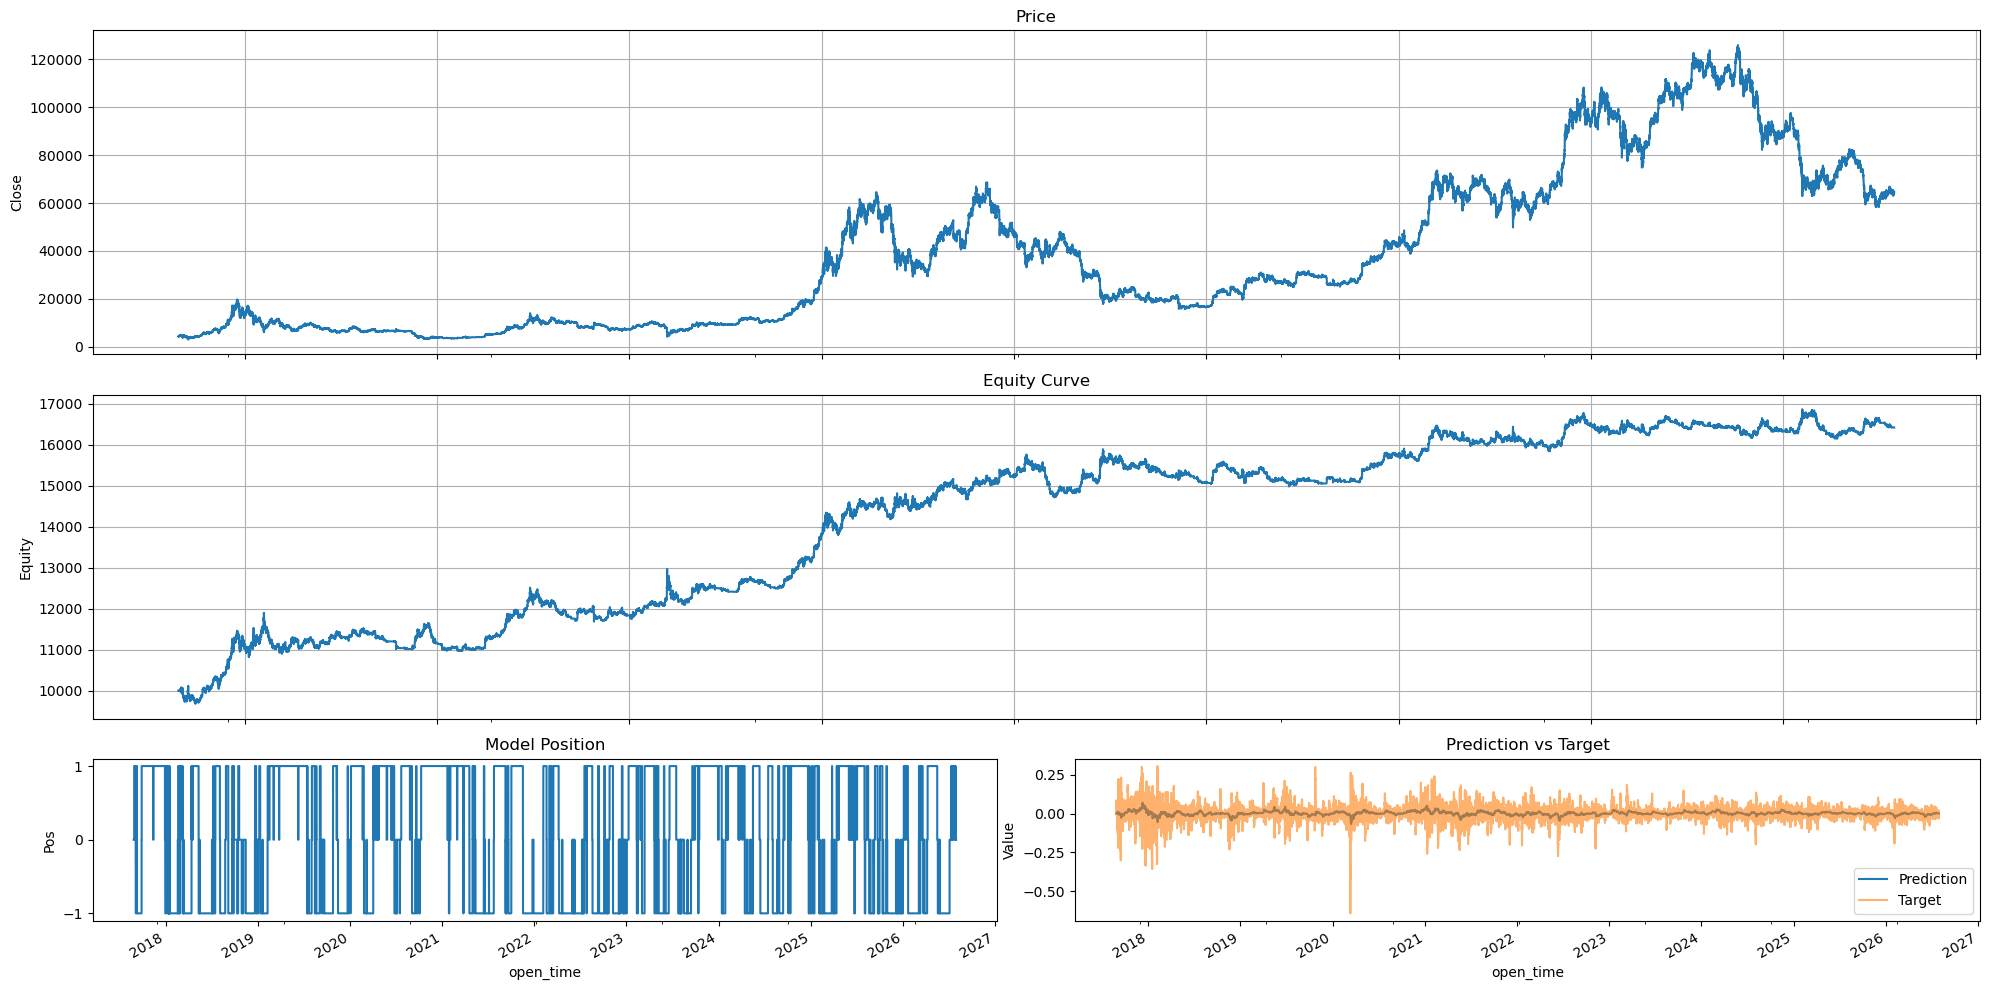

In [14]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1])

ax_price = fig.add_subplot(gs[0, :])
ax_equity = fig.add_subplot(gs[1, :], sharex=ax_price)
ax_pos = fig.add_subplot(gs[2, 0], sharex=ax_price)
ax_pred = fig.add_subplot(gs[2, 1], sharex=ax_price)

baseline_result["close"].plot(ax=ax_price, title="Price", grid=True)
baseline_result["equity"].plot(ax=ax_equity, title="Equity Curve", grid=True)
baseline_result["position"].plot(ax=ax_pos, title="Model Position", drawstyle="steps-post")

baseline_result["prediction"].plot(ax=ax_pred, label="Prediction", title="Prediction vs Target")
baseline_result[target_col].plot(ax=ax_pred, label="Target", alpha=0.6)

ax_price.set_ylabel("Close")
ax_equity.set_ylabel("Equity")
ax_pos.set_ylabel("Pos")
ax_pred.set_ylabel("Value")

ax_pos.set_yticks([-1, 0, 1])
ax_pred.legend()

plt.tight_layout()
plt.show()

# Baseline Feature Importance

In [15]:
X = df[feature_cols].astype(float).to_numpy()
y = df[target_col].astype(float).to_numpy()

importance_model = LinearRegressionModel(
    n_features=len(feature_cols),
    lr=LR,
    model_l2=MODEL_L2
)

pending_updates = deque()

for i in range(len(df)):
    # Only train on targets whose forward horizon has become observable.
    while pending_updates and pending_updates[0][0] <= i:
        _, x_ready, y_ready = pending_updates.popleft()
        importance_model.update(x_ready, y_ready)

    # Queue today's sample; do not train on it until `HORIZON` bars later.
    pending_updates.append((i + HORIZON, X[i].copy(), y[i]))

# Raw coefficients are only directly comparable if your features were scaled.
raw_coef = np.asarray(importance_model.w).reshape(-1)

feature_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "coefficient": raw_coef,
        "abs_coefficient": np.abs(raw_coef),
    })
)

display(feature_importance)

,feature,coefficient,abs_coefficient
0,ret_125,-0.000312,0.000312
1,ret_150,-0.000389,0.000389
2,ret_175,-0.000396,0.000396
3,ret_200,-0.000506,0.000506
4,ret_225,-0.000797,0.000797
5,ret_250,-0.000921,0.000921


# Hyperparameter Study

In [16]:
hyperparameter_study = []

for horizon, threshold_multiplier, lr, model_l2 in product(
    HORIZON_GRID,
    THRESHOLD_MULTIPLIER_GRID,
    LR_GRID,
    MODEL_L2_GRID
):
    tmp_df, tmp_features, tmp_target, pnl_col = build_features(
        raw_df,
        horizon
    )

    _, pred_m, trade_m = walk_forward_simulation(
        tmp_df,
        tmp_features,
        tmp_target,
        pnl_col,
        horizon,
        lr,
        model_l2,
        threshold_multiplier,
        ALLOW_SHORTS,
        INITIAL_BALANCE
    )

    row = {
        "HORIZON": horizon,
        "THRESHOLD_MULTIPLIER": threshold_multiplier,
        "LR": lr,
        "MODEL_L2": model_l2,
        **pred_m,
        **trade_m,
    }
    hyperparameter_study.append(row)

hyperparameter_study_df = pd.DataFrame(hyperparameter_study).sort_values(
    ["sharpe", "total_return", "max_drawdown", "corr"],
    ascending=[False, False, True, False]
)

best_hyper_param = hyperparameter_study_df.iloc[0].to_dict()
hyperparameter_study_df.head(10)

,HORIZON,THRESHOLD_MULTIPLIER,LR,MODEL_L2,mse,mae,corr,direction_acc,final_equity,total_return,sharpe,max_drawdown,trade_count,long_count,short_count,flat_count,avg_bar_return
40,37,1.0,0.00325,0.425,0.001979,0.030154,0.034685,0.517045,16424.979684,0.642498,0.840438,-0.083899,658,162,167,329,0.000007
58,38,0.8,0.00325,0.425,0.002031,0.030599,0.035316,0.516552,16500.471903,0.650047,0.839984,-0.088973,636,163,155,318,0.000007
16,36,1.0,0.00350,0.425,0.001933,0.029780,0.033619,0.517000,16377.457258,0.637746,0.834770,-0.078361,688,172,172,344,0.000007
70,38,1.0,0.00350,0.425,0.002039,0.030679,0.034958,0.516937,16384.022787,0.638402,0.833849,-0.078180,656,170,158,328,0.000007
29,37,0.8,0.00300,0.450,0.001972,0.030078,0.035034,0.518070,16356.905311,0.635691,0.828517,-0.101748,588,154,140,294,0.000007
2,36,0.8,0.00300,0.450,0.001920,0.029630,0.034342,0.517128,16348.306811,0.634831,0.828357,-0.099033,588,149,145,294,0.000007
69,38,1.0,0.00350,0.400,0.002038,0.030675,0.034965,0.516834,16325.072608,0.632507,0.828090,-0.075615,676,178,160,338,0.000007
68,38,1.0,0.00325,0.450,0.002032,0.030603,0.035317,0.516681,16300.850972,0.630085,0.826289,-0.087127,650,162,163,325,0.000007
31,37,0.8,0.00325,0.425,0.001979,0.030154,0.034685,0.517045,16292.158878,0.629216,0.820499,-0.087771,634,164,153,317,0.000007
30,37,0.8,0.00325,0.400,0.001979,0.030150,0.034685,0.517122,16285.900301,0.628590,0.820113,-0.098050,652,170,156,326,0.000007


# Final Test

In [17]:
df_final, feature_cols_final, target_col_final, pnl_col = build_features(
    raw_df,
    int(best_hyper_param["HORIZON"])
)

final_result, final_pred_metrics, final_trading_metrics = walk_forward_simulation(
    df=df_final,
    feature_cols=feature_cols_final,
    target_col=target_col_final,
    pnl_return_col=pnl_col,
    horizon=best_hyper_param["HORIZON"],
    lr=best_hyper_param["LR"],
    model_l2=best_hyper_param["MODEL_L2"],
    threshold_multiplier=best_hyper_param["THRESHOLD_MULTIPLIER"],
    allow_shorts=ALLOW_SHORTS,
    initial_balance=INITIAL_BALANCE
)

print("Final Prediction Metrics")
print(pd.Series(final_pred_metrics))

print("\nFinal Trading Metrics")
print(pd.Series(final_trading_metrics))

Final Prediction Metrics
mse              0.001979
mae              0.030154
corr             0.034685
direction_acc    0.517045
dtype: float64

Final Trading Metrics
final_equity      16424.979684
total_return          0.642498
sharpe                0.840438
max_drawdown         -0.083899
trade_count         658.000000
long_count          162.000000
short_count         167.000000
flat_count          329.000000
avg_bar_return        0.000007
dtype: float64


# Final Equity Plot

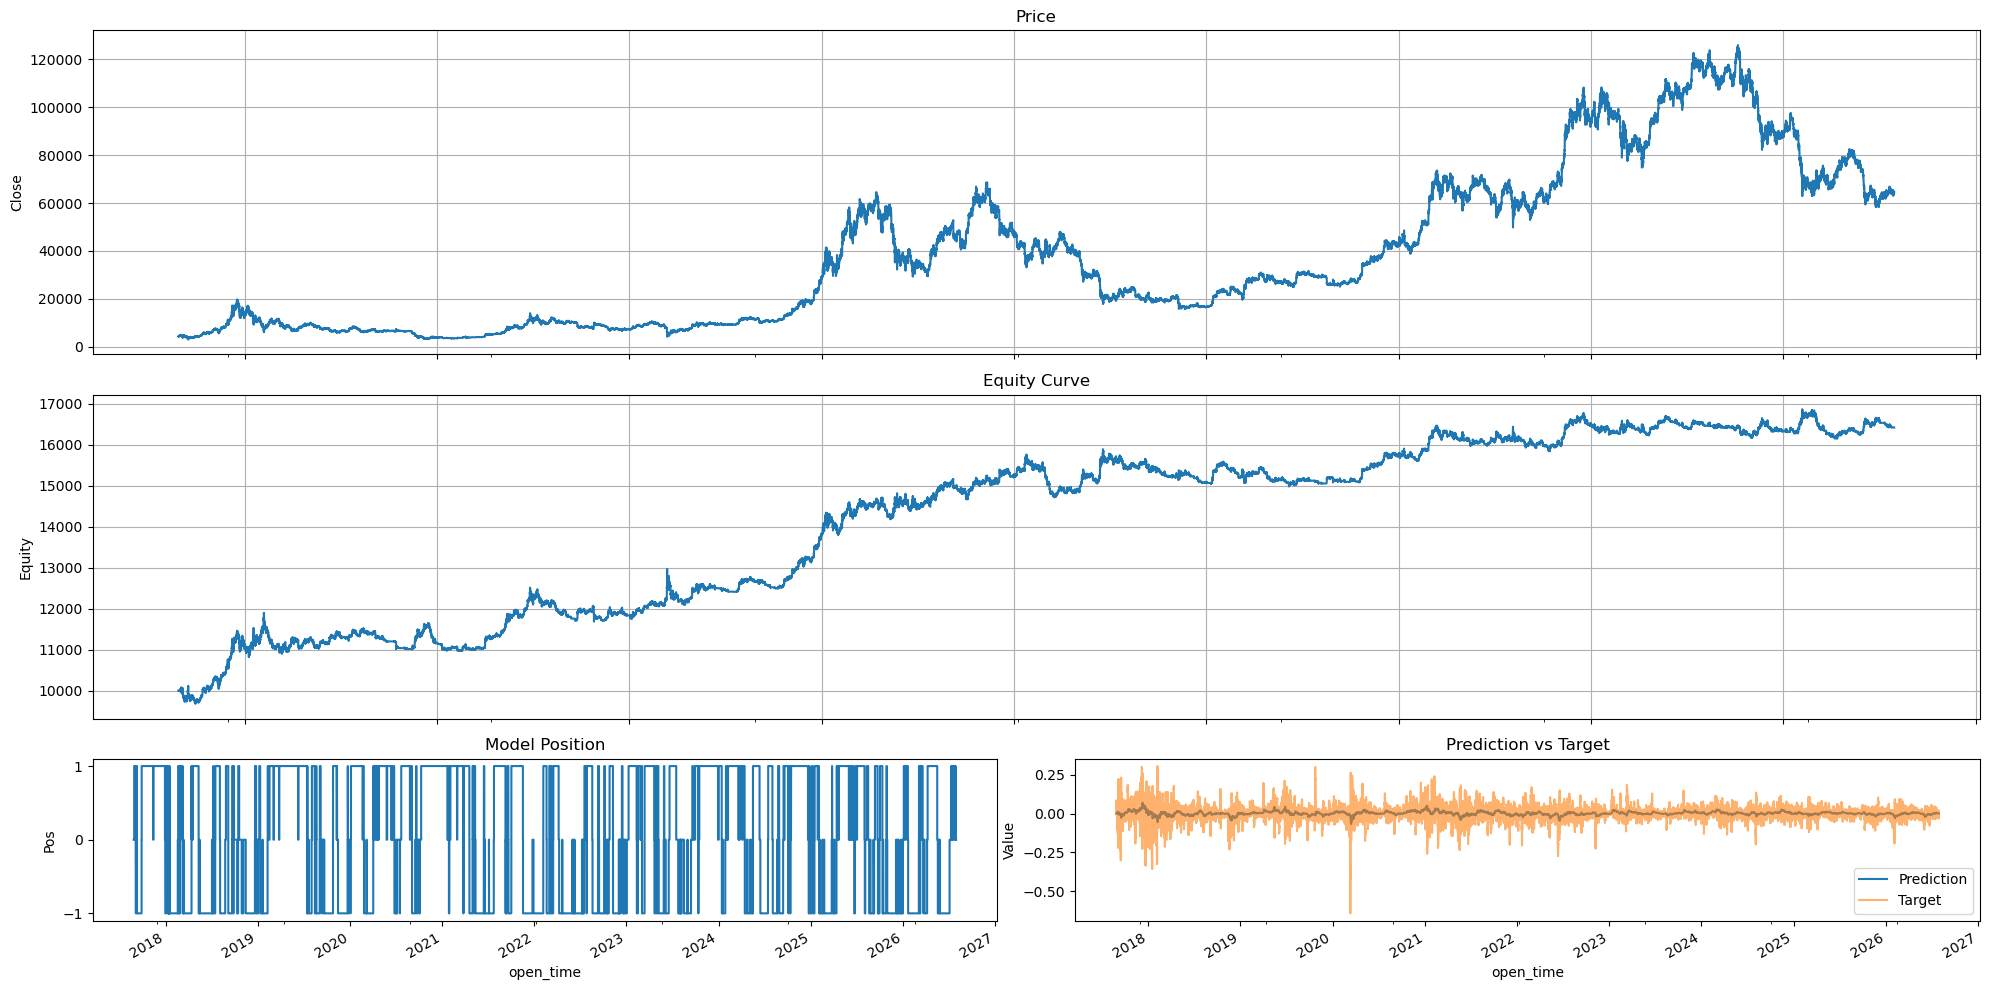

In [18]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1])

ax_price = fig.add_subplot(gs[0, :])
ax_equity = fig.add_subplot(gs[1, :], sharex=ax_price)
ax_pos = fig.add_subplot(gs[2, 0], sharex=ax_price)
ax_pred = fig.add_subplot(gs[2, 1], sharex=ax_price)

final_result["close"].plot(ax=ax_price, title="Price", grid=True)
final_result["equity"].plot(ax=ax_equity, title="Equity Curve", grid=True)
final_result["position"].plot(ax=ax_pos, title="Model Position", drawstyle="steps-post")

final_result["prediction"].plot(ax=ax_pred, label="Prediction", title="Prediction vs Target")
final_result[target_col].plot(ax=ax_pred, label="Target", alpha=0.6)

ax_price.set_ylabel("Close")
ax_equity.set_ylabel("Equity")
ax_pos.set_ylabel("Pos")
ax_pred.set_ylabel("Value")

ax_pos.set_yticks([-1, 0, 1])
ax_pred.legend()

plt.tight_layout()
plt.show()

# Research Summary Table

In [19]:
summary = pd.DataFrame({
    "baseline_pred": pd.Series(baseline_pred_metrics),
    "final_pred": pd.Series(final_pred_metrics),
})

summary

,baseline_pred,final_pred
mse,0.001979,0.001979
mae,0.030154,0.030154
corr,0.034685,0.034685
direction_acc,0.517045,0.517045


# Trading Summary Table

In [20]:
trading_summary = pd.DataFrame({
    "baseline_trading": pd.Series(baseline_trading_metrics),
    "final_trading": pd.Series(final_trading_metrics),
})

trading_summary

,baseline_trading,final_trading
final_equity,16424.979684,16424.979684
total_return,0.642498,0.642498
sharpe,0.840438,0.840438
max_drawdown,-0.083899,-0.083899
trade_count,658.000000,658.000000
long_count,162.000000,162.000000
short_count,167.000000,167.000000
flat_count,329.000000,329.000000
avg_bar_return,0.000007,0.000007


# Final Feature Importance

In [21]:
X_final = df_final[feature_cols_final].astype(float).to_numpy()
y_final = df_final[target_col_final].astype(float).to_numpy()

importance_model = LinearRegressionModel(
    n_features=len(feature_cols_final),
    lr=float(best_hyper_param["LR"]),
    model_l2=float(best_hyper_param["MODEL_L2"])
)

pending_updates = deque()

for i in range(len(df)):
    # Only train on targets whose forward horizon has become observable.
    while pending_updates and pending_updates[0][0] <= i:
        _, x_ready, y_ready = pending_updates.popleft()
        importance_model.update(x_ready, y_ready)

    # Queue today's sample; do not train on it until `HORIZON` bars later.
    pending_updates.append((i + HORIZON, X[i].copy(), y_final[i]))

# Raw coefficients are only directly comparable if your features were scaled.
raw_coef = np.asarray(importance_model.w).reshape(-1)

feature_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "coefficient": raw_coef,
        "abs_coefficient": np.abs(raw_coef),
    })
)

display(feature_importance)

,feature,coefficient,abs_coefficient
0,ret_125,-0.000312,0.000312
1,ret_150,-0.000389,0.000389
2,ret_175,-0.000396,0.000396
3,ret_200,-0.000506,0.000506
4,ret_225,-0.000797,0.000797
5,ret_250,-0.000921,0.000921
